# BIS Central-Bank Speech Archive: Exploration and Policy Tone

This executed notebook is the review companion to `run_analysis.py` and `REPORT.md`. It loads the assignment-required `./BIS_speeches.csv` through the reusable package for the basic audit, then reads the deterministic outputs of the full pipeline. Run `python run_analysis.py` before re-executing this notebook.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from bis_speeches.data import basic_summary, load_and_clean, quality_summary

TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
summary = json.loads((ROOT / "outputs" / "summary.json").read_text())
pd.set_option("display.max_columns", 20)

## A. Basic data exploration

In [2]:
speeches = load_and_clean(ROOT / "BIS_speeches.csv")
headline, length_summary = basic_summary(speeches)
display(headline)
display(length_summary)
display(quality_summary(speeches))

,metric,value
0,Total speeches,20728
1,Start date,1996-09-10
2,End date,2026-06-22
3,Unique speakers,1019
4,Speeches mentioning inflation,11489
5,Share mentioning inflation,0.554274


,statistic,words
0,minimum,38.000000
1,maximum,48830.000000
2,mean,2803.913016
3,median,2447.500000
4,standard_deviation,1871.823663


,check,value
0,rows,20728
1,missing_date,0
2,missing_author,25
3,missing_title,0
4,missing_text,0
5,missing_description,3
6,duplicate_rows,0
7,duplicate_urls,0
8,duplicate_texts,26
9,corrected_dates,2


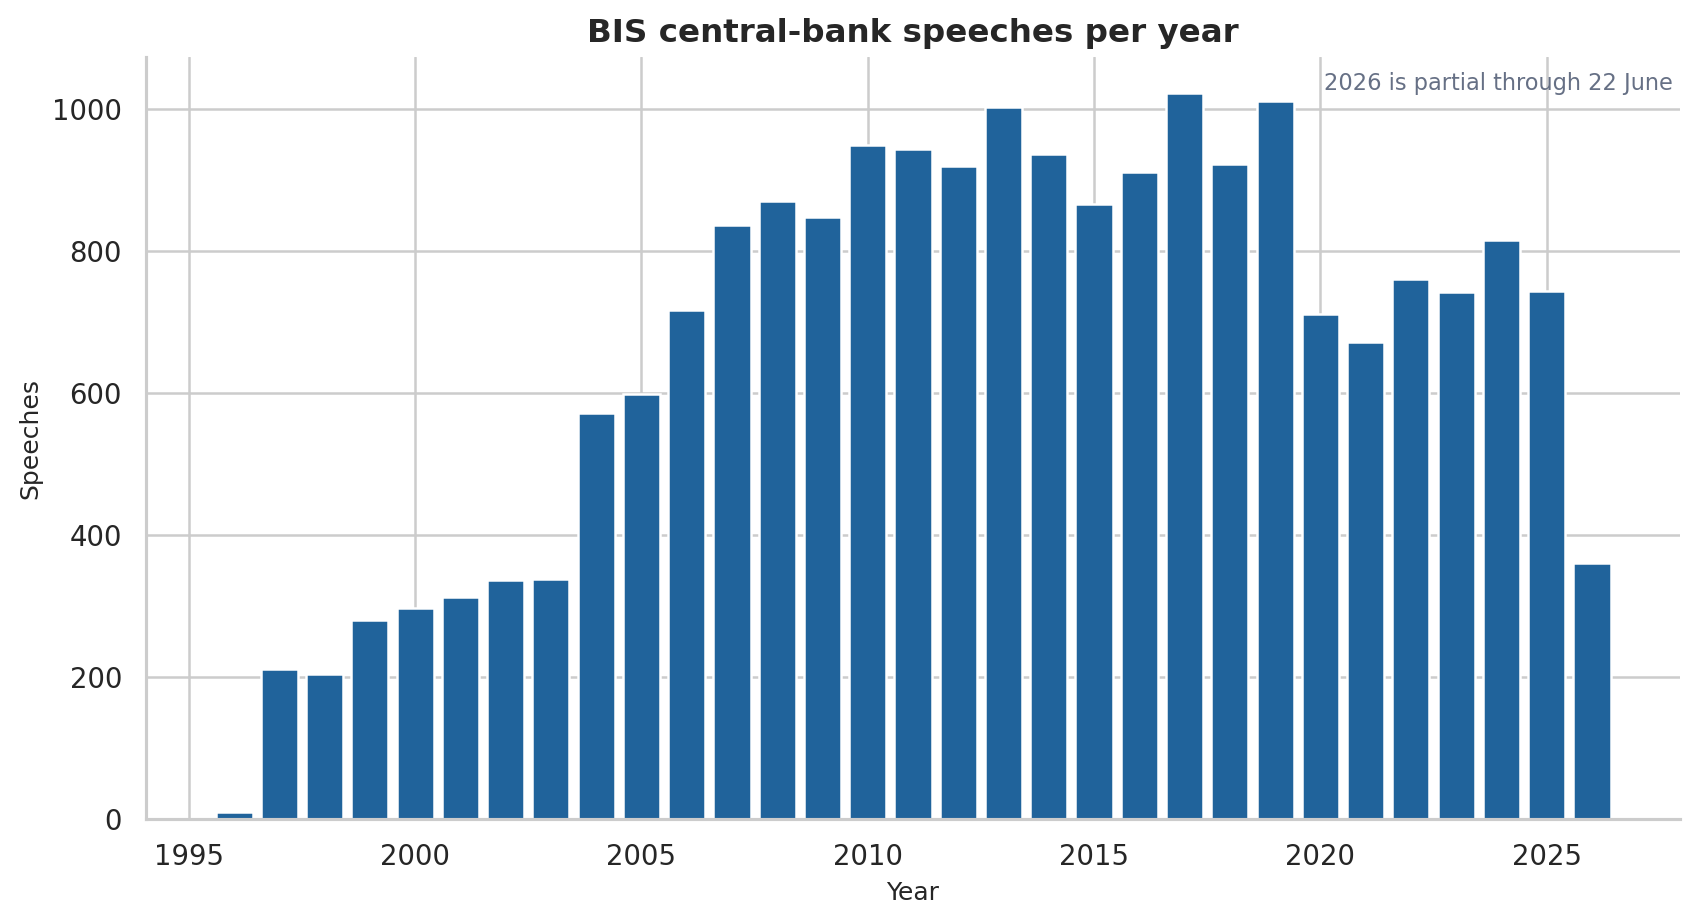

In [3]:
display(Image(filename=str(FIGURES / 'speeches_per_year.png')))

The economically motivated additional feature is whether a speech mentions inflation: it connects the communication corpus to a central price-stability objective. BIS warns that the archive is neither guaranteed complete nor free of machine-extraction artifacts, and 2026 is a partial year.

## B. Country attribution via metadata

,method,speeches,share
0,institution_alias,20528,0.990351
1,speaker_fallback,168,0.008105
2,unresolved,32,0.001544
3,direct_conflicts,579,0.027933
4,total,20728,1.000000


,rank,jurisdiction,speeches,speakers
0,1,United States,2488,71
1,2,India,1010,44
2,3,Germany,936,34
3,4,United Kingdom,847,49
4,5,Japan,814,48
5,6,Canada,612,29
6,7,Australia,589,18
7,8,Malaysia,583,30
8,9,Philippines,569,8
9,10,Sweden,520,25


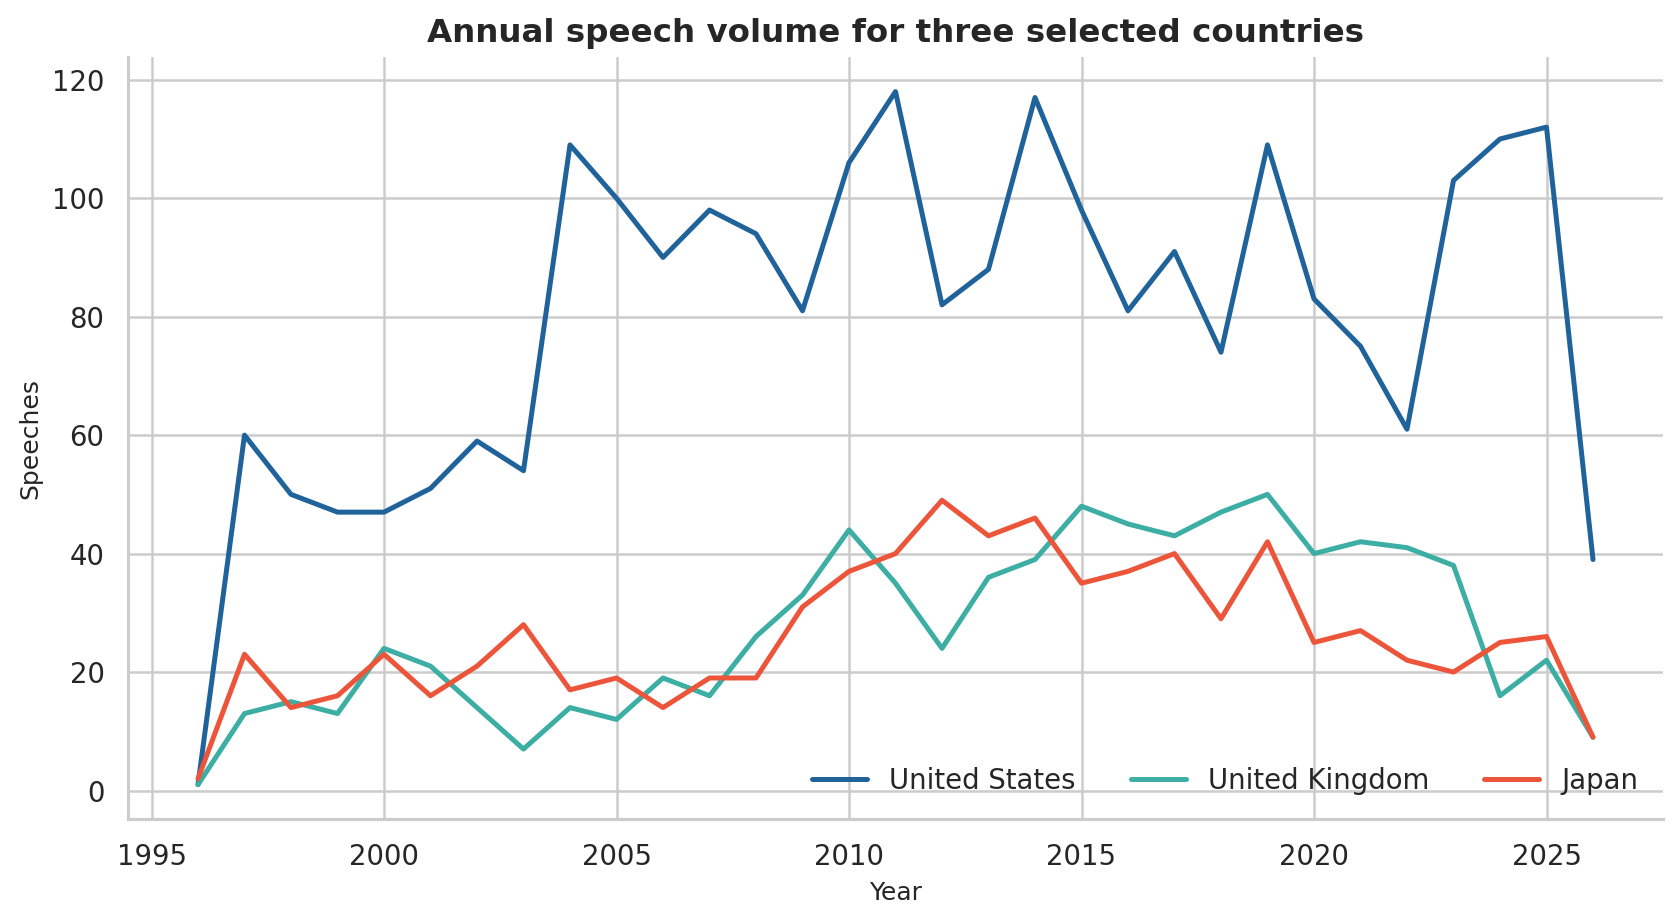

In [4]:
display(pd.read_csv(TABLES / "country_attribution_qa.csv"))
display(pd.read_csv(TABLES / "top10_countries.csv"))
display(Image(filename=str(FIGURES / "selected_countries_per_year.png")))

Country means the jurisdiction of the speaker's institution, not nationality or event venue. The method searches a bounded byline against a curated institution-alias registry, records multi-match conflicts, and uses a speaker fallback only when at least three direct observations agree at least 95%. National, territorial, regional, supranational, international, and unresolved records remain distinct.

## C. Inflation-persistence keyword signal

,pattern_name,regular_expression
0,persistent_or_sticky_inflation,\b(?:persistent|persistently|persistence|stick...
1,inflation_remains_high,\binflation\s+(?:remains?|remained|continues?\...
2,inflation_expected_to_remain_high,\binflation\s+(?:is\s+)?(?:expected|projected|...
3,persistent_price_pressures,\b(?:price|inflationary|cost)\s+pressures?\s+(...
4,inflation_for_longer,"\b(?:inflation|price\s+pressures?)\b.{0,45}\b(..."
5,second_round_or_deanchoring,\b(?:second[ -]round\s+effects?|de[ -]?anchor(...


,year,speeches,persistence_speeches,persistence_share
21,2017,1022,41,0.040117
22,2018,923,39,0.042254
23,2019,1011,29,0.028684
24,2020,711,24,0.033755
25,2021,672,42,0.062500
26,2022,761,155,0.203679
27,2023,742,174,0.234501
28,2024,816,102,0.125000
29,2025,744,77,0.103495
30,2026,361,76,0.210526


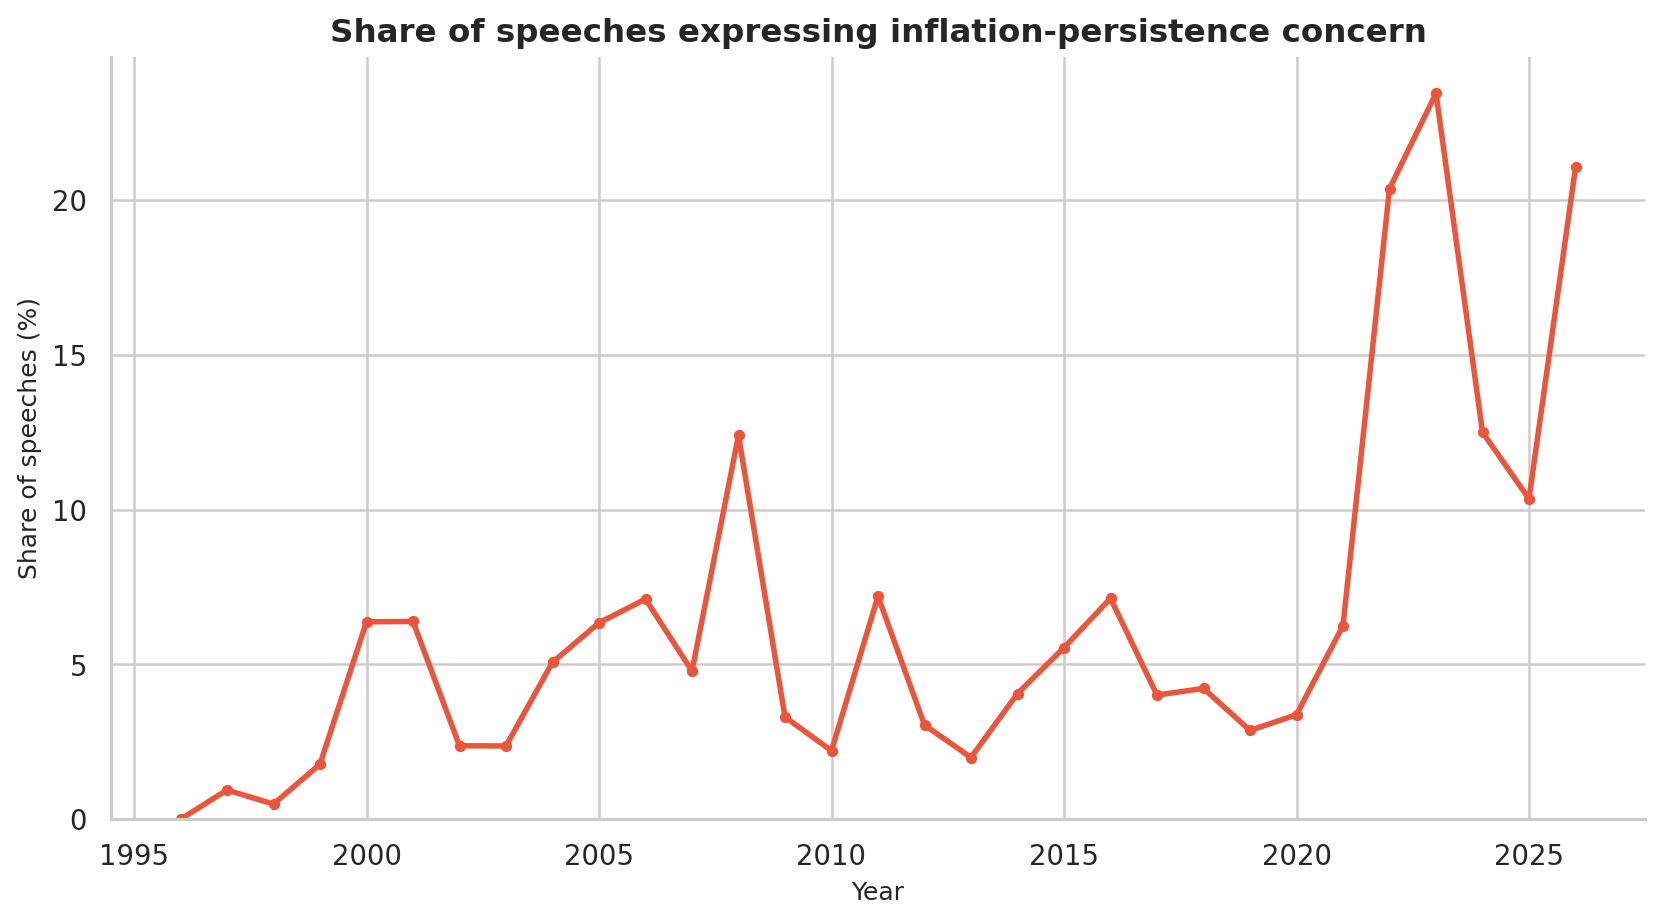

In [5]:
persistence = pd.read_csv(TABLES / "inflation_persistence_annual.csv")
display(pd.read_csv(TABLES / "inflation_persistence_patterns.csv"))
display(persistence.tail(10))
display(Image(filename=str(FIGURES / "inflation_persistence_share.png")))

The indicator rises sharply in 2022–23 and subsequently recedes; the elevated 2026 share is partial-year evidence. Keyword matching is transparent but can miss paraphrases and mishandle negation, quotation, or hypothetical scenarios.

## Additional A. Speech-level tone model

,alpha,validation_accuracy,validation_macro_f1,validation_weighted_f1
0,0.000003,0.615733,0.613985,0.615765
1,0.000010,0.625867,0.625236,0.625882
2,0.000030,0.630400,0.627331,0.630490
3,0.000100,0.633067,0.633925,0.633174
4,0.000300,0.626933,0.618776,0.627150


,test_accuracy,test_macro_f1,test_weighted_f1,test_log_loss,test_multiclass_brier,test_top_label_ece_15_bins
0,0.6296,0.616358,0.628462,0.893538,0.503883,0.029308


,class,precision,recall,f1,support
0,dovish,0.633768,0.620607,0.627119,1252
1,hawkish,0.644172,0.586592,0.614035,1074
2,irrelevant,0.878788,0.429630,0.577114,135
3,neutral,0.605405,0.695112,0.647165,1289


,example_type,sentence,true_label,predicted_label,p_dovish,p_hawkish,p_irrelevant,p_neutral
0,hawkish,persistently elevated inflation expectations a...,hawkish,hawkish,0.035088,0.950061,0.000406,0.014446
1,dovish,2) the annual average of headline inflation wa...,dovish,dovish,0.915888,0.065773,0.000012,0.018327


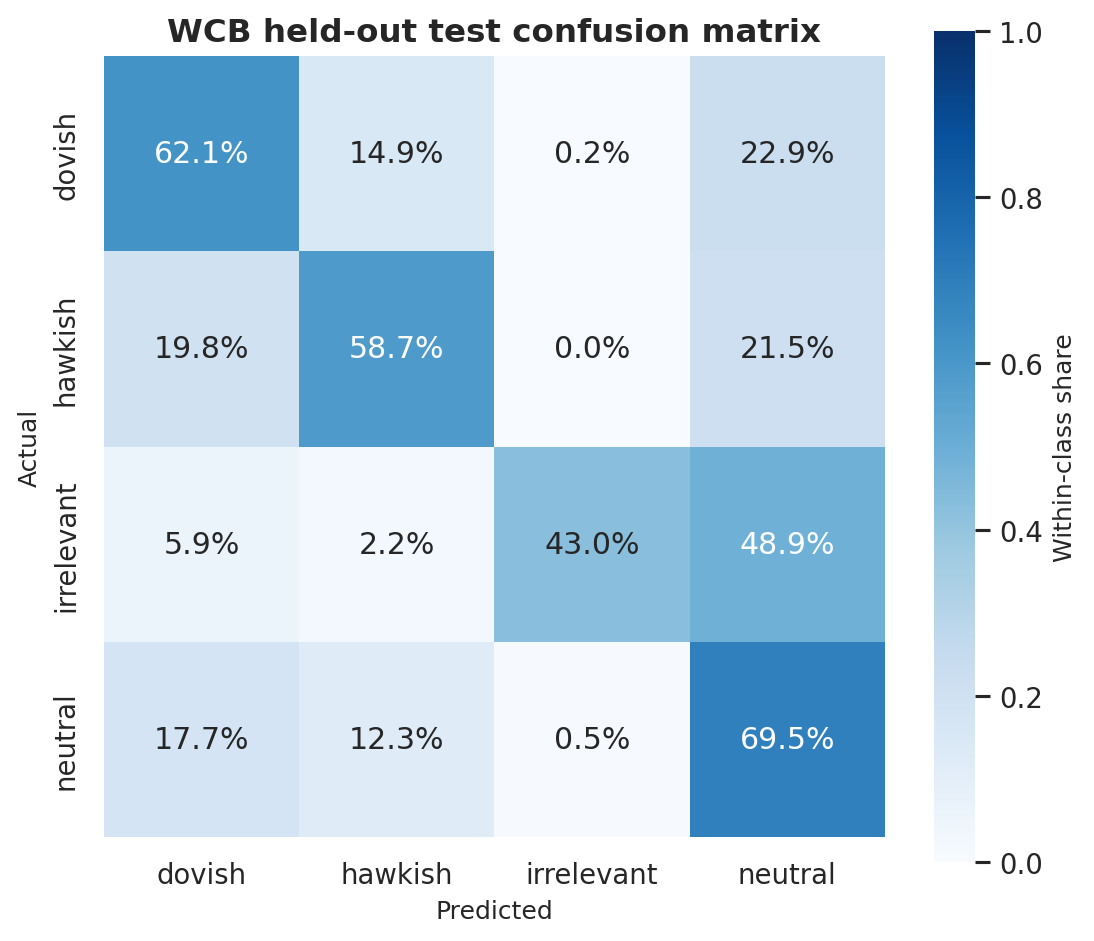

In [6]:
display(pd.read_csv(TABLES / "tone_validation_grid.csv"))
display(pd.read_csv(TABLES / "tone_test_metrics.csv"))
display(pd.read_csv(TABLES / "tone_class_metrics.csv"))
display(pd.read_csv(TABLES / "tone_examples.csv"))
display(Image(filename=str(FIGURES / "tone_confusion_matrix.png")))

The supervised classifier uses WCB hawkish/dovish/neutral/irrelevant sentence labels, word and character TF-IDF, a class-balanced averaged logistic-loss SGD model, and sigmoid calibration. Contrastive clauses are scored separately. Speech hawkishness is `H/(H+D)`; mixedness is `1-|H-D|/(H+D)`; signal strength is `(H+D)/clauses`. This distinguishes no-signal speeches from speeches that contain both hawkish and dovish scenarios.

## Additional B. Speaker-level trends

,rank,author,speeches,tone_valid_speeches,mean_hawkishness,mean_mixedness
0,1,Jean-Claude Trichet,478,454,0.506531,0.798129
1,2,Mario Draghi,337,318,0.395822,0.760243
2,3,"Amando M Tetangco, Jr",272,177,0.441435,0.754184
3,4,Benoît Cœuré,254,235,0.376798,0.723882
4,5,Ben S Bernanke,252,218,0.440542,0.770275
5,6,François Villeroy de Galhau,228,191,0.442168,0.774185
6,7,Zeti Akhtar Aziz,224,80,0.421001,0.605191
7,8,Andreas Dombret,222,166,0.426947,0.721454
8,9,Yves Mersch,194,168,0.389344,0.734259
9,10,Alan Greenspan,192,161,0.496828,0.801831


,speaker,total_speeches,tone_valid_speeches,halfyear_periods,slope_per_year,hac_t_statistic,p_value,r_squared,fdr_q_value,significant_fdr_5pct,trend_direction
0,Jean-Claude Trichet,478,454,27,0.004048,1.532987,0.125279,0.084572,0.250558,False,more hawkish
1,Mario Draghi,337,318,27,-0.004298,-1.357654,0.174574,0.081828,0.290956,False,more dovish
2,"Amando M Tetangco, Jr",272,177,24,-0.004183,-1.107353,0.268141,0.046725,0.335177,False,more dovish
3,Benoît Cœuré,254,235,16,0.002887,1.144232,0.252527,0.060764,0.335177,False,more hawkish
4,Ben S Bernanke,252,218,23,-0.012927,-7.265453,0.000000,0.506377,0.000000,True,more dovish
5,François Villeroy de Galhau,228,191,22,0.018007,4.244922,0.000022,0.515950,0.000109,True,more hawkish
6,Zeti Akhtar Aziz,224,80,29,0.000638,0.084821,0.932403,0.000312,0.932403,False,more hawkish
7,Andreas Dombret,222,166,16,-0.013801,-3.255465,0.001132,0.338009,0.003774,True,more dovish
8,Yves Mersch,194,168,31,-0.007901,-2.859840,0.004239,0.263580,0.010596,True,more dovish
9,Alan Greenspan,192,161,18,-0.004458,-0.756492,0.449354,0.046044,0.499283,False,more dovish


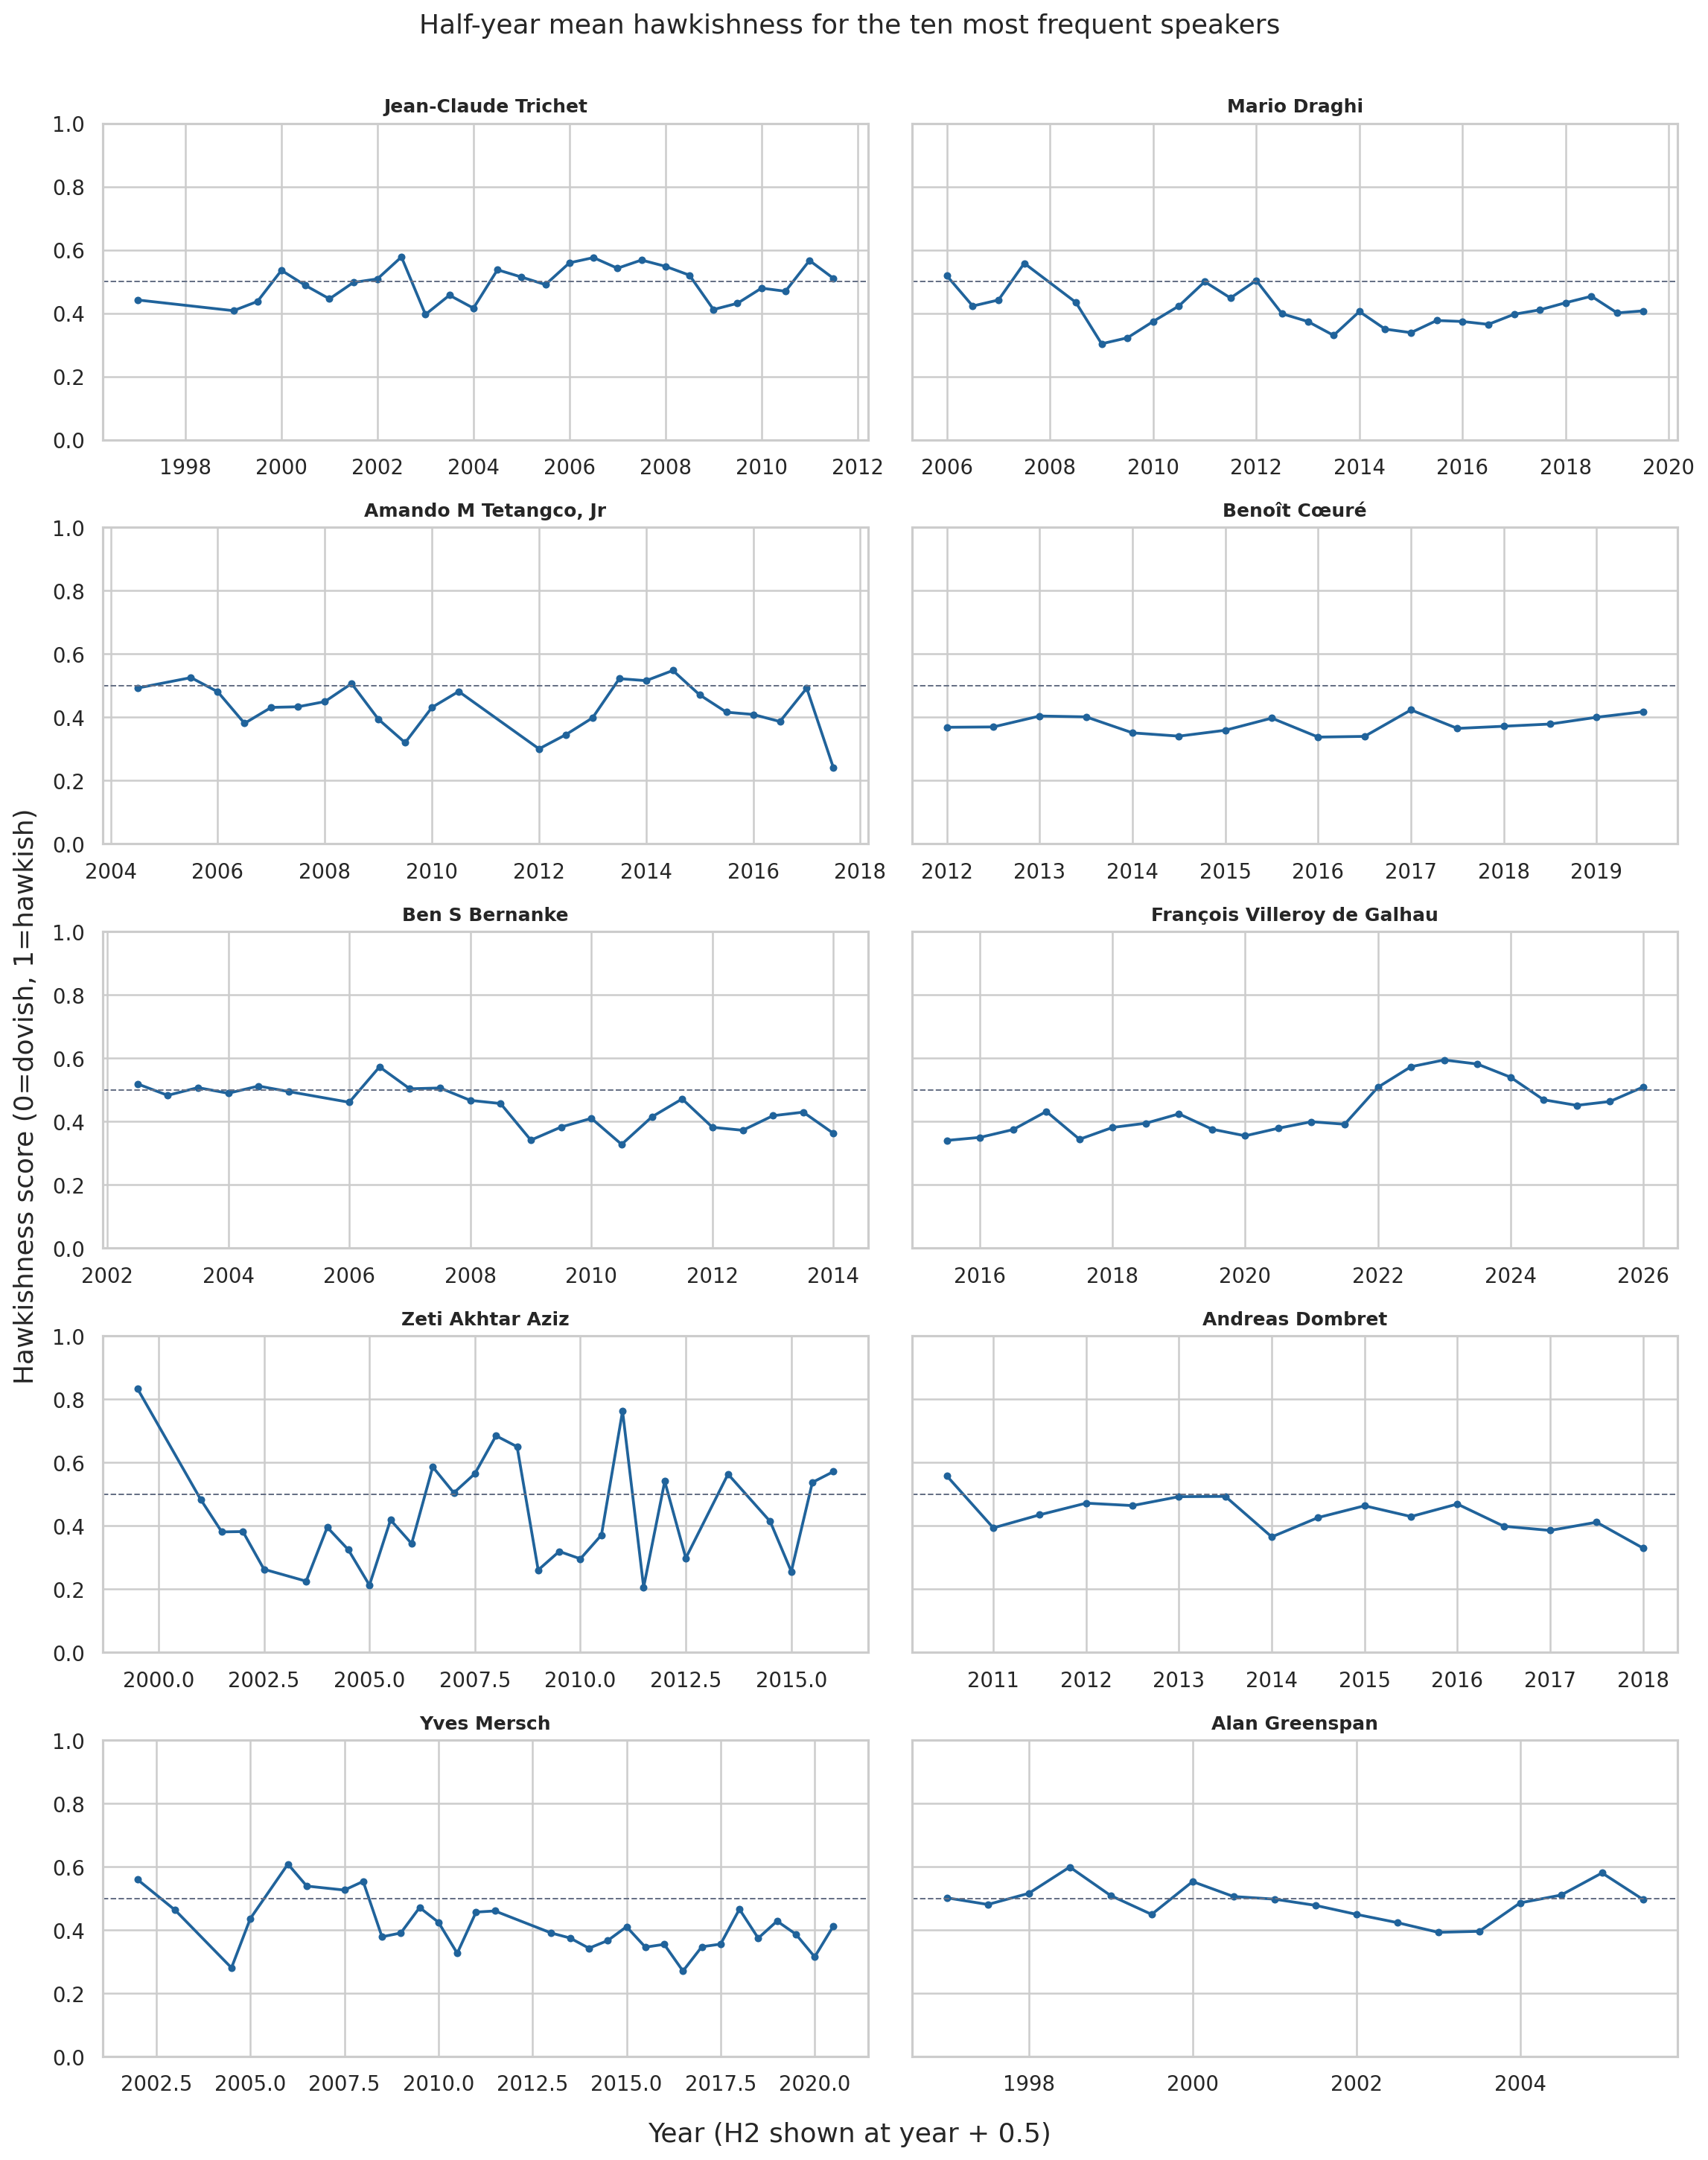

In [7]:
display(pd.read_csv(TABLES / "top10_speakers.csv"))
trends = pd.read_csv(TABLES / "speaker_trend_tests.csv")
display(trends)
display(Image(filename=str(FIGURES / "speaker_tone_halfyear.png")))

Half-year windows balance noise reduction and temporal resolution. Linear trend tests use two-lag HAC standard errors, and Benjamini–Hochberg q-values control false discoveries across the ten speakers. These are descriptive within-speaker trends, not causal estimates.

## Additional C. Country-level tone and stability

### Relatively most hawkish

,rank,jurisdiction,speeches,speakers,years_observed,mean_hawkishness,median_hawkishness,mean_mixedness,mean_signal_strength,central_bank,years_with_3plus_speeches,annual_tone_sd,annual_tone_range,bootstrap_ci_lower,bootstrap_ci_upper
0,1,Türkiye,106,9,24,0.539260,0.533476,0.834789,0.577516,Central Bank of the Republic of Turkey,16,0.043733,0.174710,0.521504,0.557525
1,2,Norway,301,9,28,0.529876,0.536914,0.825798,0.578335,Norges Bank,28,0.075111,0.296927,0.518152,0.542020
2,3,Iceland,92,13,26,0.520533,0.530510,0.846828,0.519782,Central Bank of Iceland,15,0.054098,0.156383,0.500032,0.537962
3,4,Chile,146,11,23,0.515034,0.527968,0.841459,0.530314,Central Bank of Chile,20,0.064263,0.306544,0.498975,0.531428
4,5,South Africa,397,12,30,0.504634,0.517974,0.824665,0.555813,South African Reserve Bank,29,0.046225,0.209809,0.493759,0.516381
5,6,Sweden,495,25,30,0.503417,0.516540,0.847194,0.525220,Sveriges Riksbank,30,0.039599,0.165279,0.493632,0.512030
6,7,Mexico,89,10,15,0.487235,0.504388,0.819699,0.569126,Bank of Mexico,11,0.075600,0.254443,0.462430,0.509514
7,8,Denmark,104,9,26,0.481385,0.475365,0.773918,0.614339,National Bank of Denmark,19,0.100064,0.385072,0.452859,0.508386
8,9,Romania,56,6,19,0.479562,0.484349,0.802178,0.531296,National Bank of Romania,8,0.054384,0.163046,0.445198,0.511302
9,10,Netherlands,175,12,30,0.476358,0.474199,0.728197,0.535782,Netherlands Bank,23,0.090791,0.393689,0.451964,0.501000


### Relatively most dovish

,rank,jurisdiction,speeches,speakers,years_observed,mean_hawkishness,median_hawkishness,mean_mixedness,mean_signal_strength,central_bank,years_with_3plus_speeches,annual_tone_sd,annual_tone_range,bootstrap_ci_lower,bootstrap_ci_upper
0,1,China,103,19,21,0.364433,0.353279,0.642327,0.560555,People's Bank of China,15,0.098746,0.348696,0.333060,0.394931
1,2,Kenya,76,6,16,0.396030,0.378295,0.628660,0.547164,Central Bank of Kenya,9,0.093750,0.306656,0.351369,0.440069
2,3,Japan,780,47,31,0.405878,0.406376,0.754799,0.562627,Bank of Japan,30,0.071023,0.272151,0.397449,0.414662
3,4,Greece,169,11,28,0.409142,0.397135,0.724290,0.593170,Bank of Greece,18,0.092910,0.349833,0.386926,0.431273
4,5,Albania,266,8,24,0.410589,0.396518,0.739920,0.537198,Bank of Albania,23,0.069386,0.228798,0.394822,0.426715
5,6,Portugal,67,8,17,0.411237,0.425148,0.741731,0.504628,Bank of Portugal,9,0.097797,0.374750,0.380477,0.442987
6,7,Zambia,102,7,17,0.411773,0.385743,0.678757,0.617469,Bank of Zambia,10,0.054006,0.164521,0.380386,0.444986
7,8,Israel,92,7,20,0.415248,0.395979,0.761892,0.543927,Bank of Israel,13,0.034780,0.118097,0.392493,0.439315
8,9,Fiji,78,5,17,0.416810,0.411632,0.677686,0.592294,Reserve Bank of Fiji,10,0.076529,0.244759,0.377868,0.458986
9,10,Malaysia,206,22,27,0.421554,0.400544,0.641016,0.606038,Central Bank of Malaysia,25,0.089568,0.385449,0.396241,0.448634


### Most stable annual mean tone

,rank,jurisdiction,speeches,speakers,years_observed,mean_hawkishness,median_hawkishness,mean_mixedness,mean_signal_strength,central_bank,years_with_3plus_speeches,annual_tone_sd,annual_tone_range,bootstrap_ci_lower,bootstrap_ci_upper
0,1,Israel,92,7,20,0.415248,0.395979,0.761892,0.543927,Bank of Israel,13,0.034780,0.118097,0.392493,0.439315
1,2,Sweden,495,25,30,0.503417,0.516540,0.847194,0.525220,Sveriges Riksbank,30,0.039599,0.165279,0.493632,0.512030
2,3,United Kingdom,751,43,31,0.462525,0.469781,0.798250,0.505709,Bank of England,30,0.042102,0.158253,0.453053,0.471003
3,4,Türkiye,106,9,24,0.539260,0.533476,0.834789,0.577516,Central Bank of the Republic of Turkey,16,0.043733,0.174710,0.521504,0.557525
4,5,India,811,43,31,0.448815,0.457675,0.762340,0.523142,Reserve Bank of India,30,0.044983,0.150905,0.438921,0.458300
5,6,Italy,384,19,29,0.441062,0.435710,0.780972,0.551555,Bank of Italy,26,0.045600,0.197021,0.429558,0.453072
6,7,South Africa,397,12,30,0.504634,0.517974,0.824665,0.555813,South African Reserve Bank,29,0.046225,0.209809,0.493759,0.516381
7,8,Germany,779,32,31,0.454258,0.453864,0.776068,0.492638,Deutsche Bundesbank,30,0.047120,0.208979,0.444793,0.463778
8,9,United States,2061,68,31,0.457997,0.463241,0.790601,0.550533,Board of Governors of the Federal Reserve System,30,0.047815,0.213143,0.452419,0.463569
9,10,Zambia,102,7,17,0.411773,0.385743,0.678757,0.617469,Bank of Zambia,10,0.054006,0.164521,0.380386,0.444986


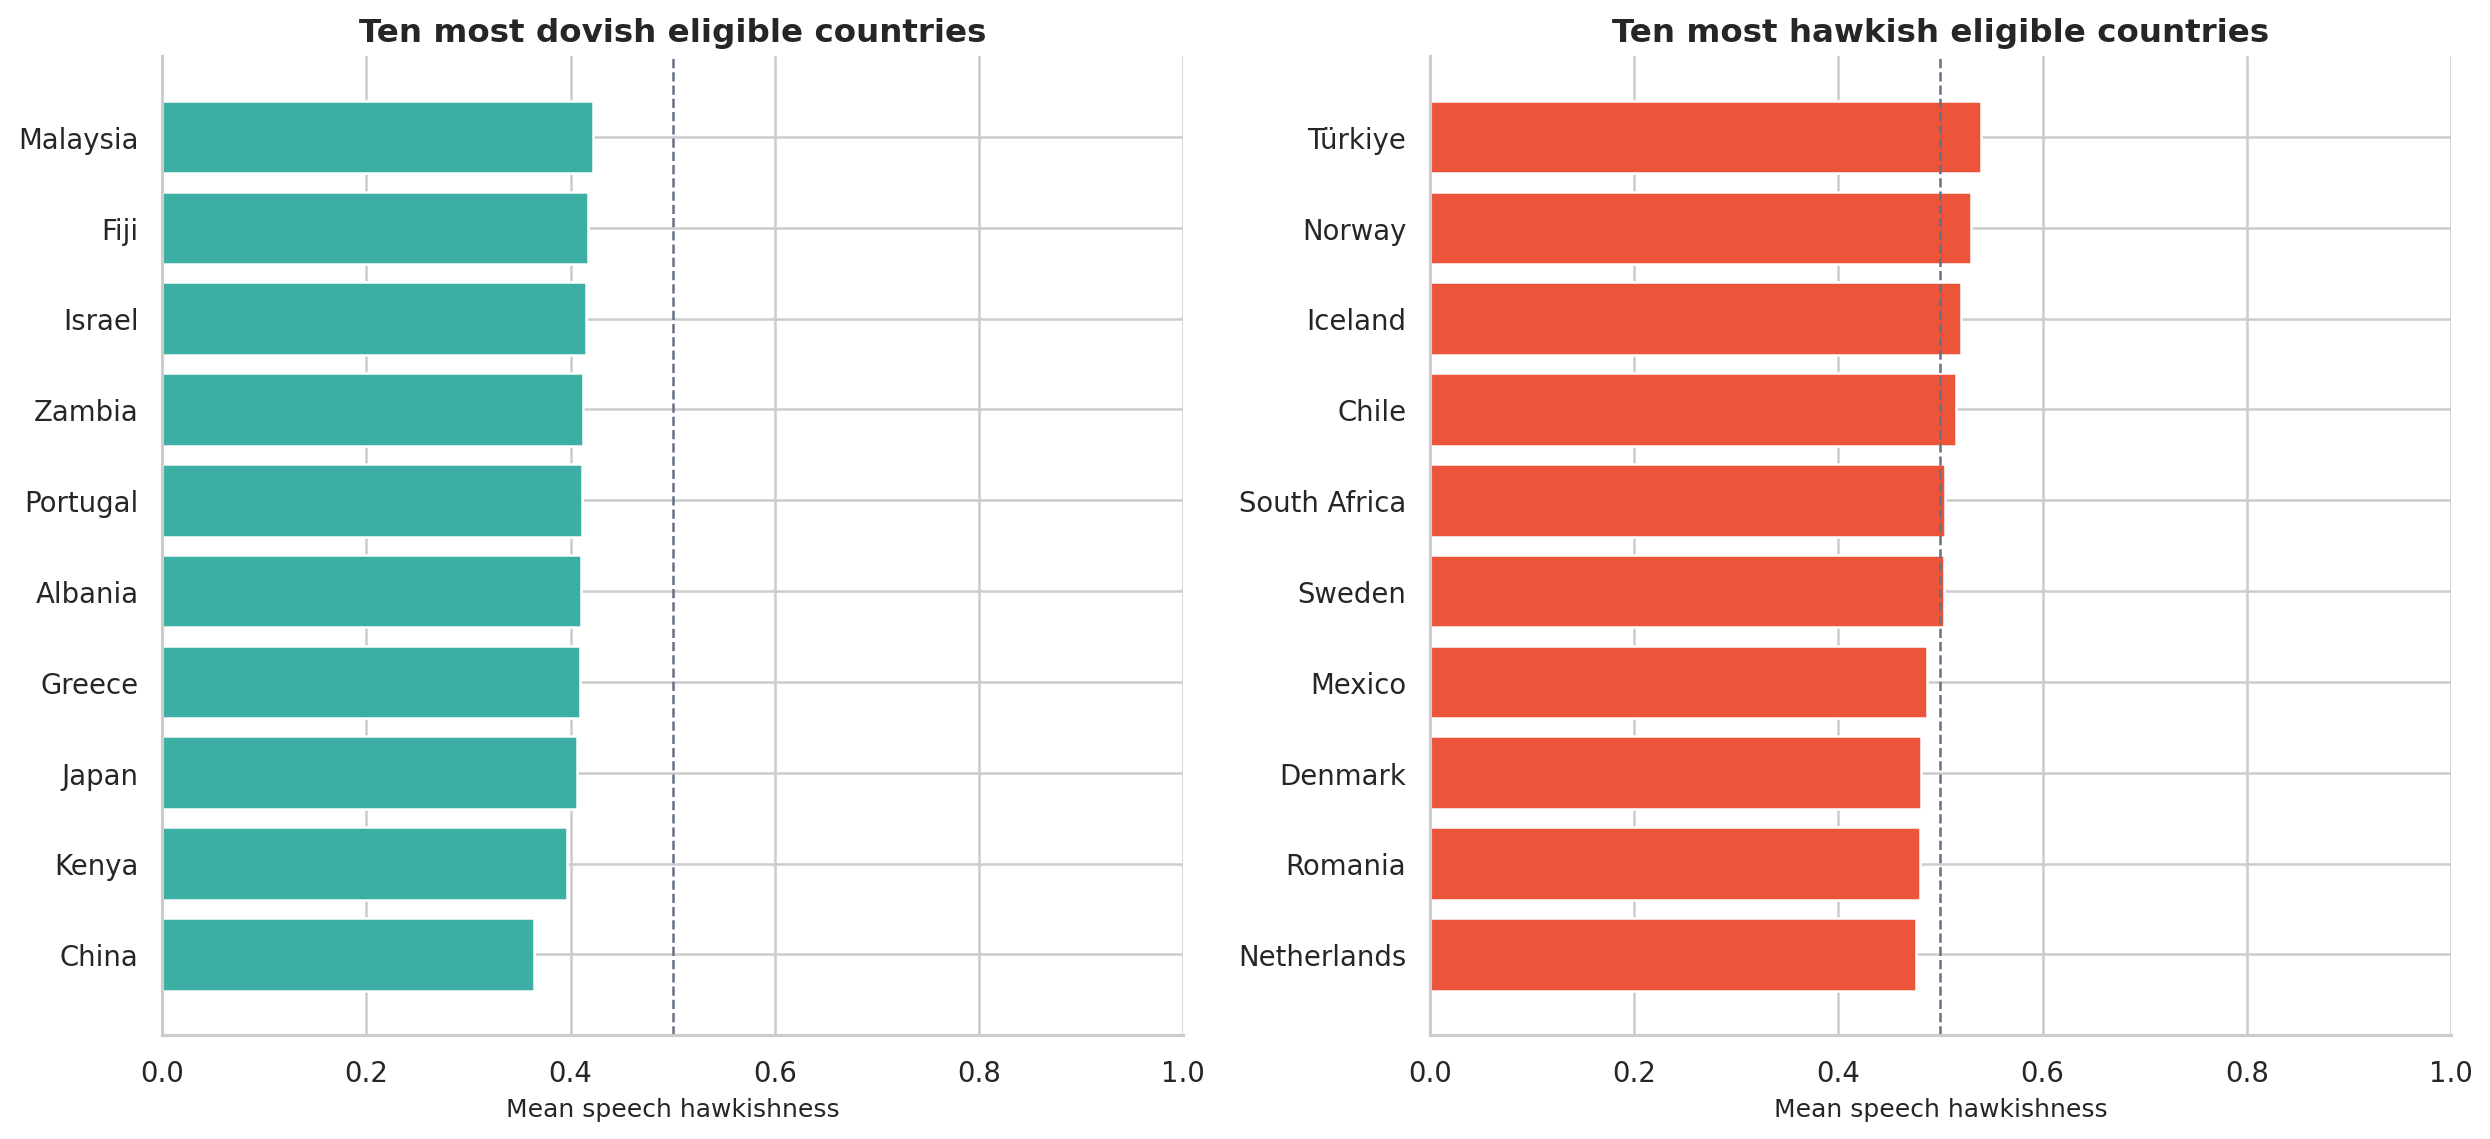

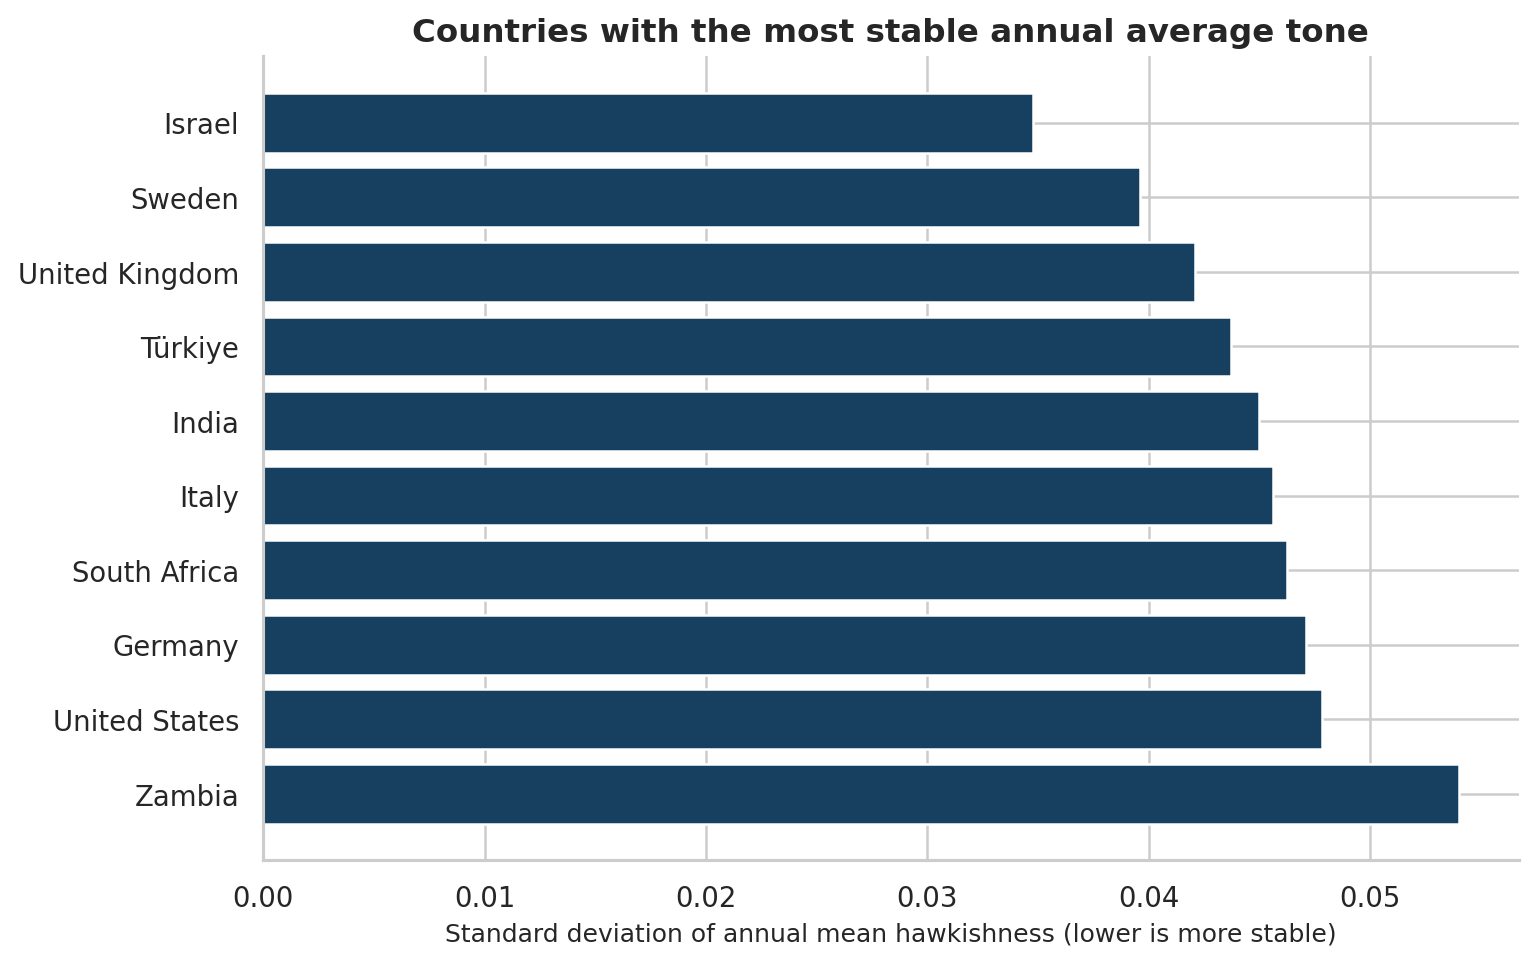

In [8]:
display(Markdown("### Relatively most hawkish"))
display(pd.read_csv(TABLES / "top10_hawkish_countries.csv"))
display(Markdown("### Relatively most dovish"))
display(pd.read_csv(TABLES / "top10_dovish_countries.csv"))
display(Markdown("### Most stable annual mean tone"))
display(pd.read_csv(TABLES / "top10_stable_countries.csv"))
display(Image(filename=str(FIGURES / "country_tone_extremes.png")))
display(Image(filename=str(FIGURES / "country_tone_stability.png")))

Rankings require at least 50 tone-valid speeches and 10 observed years. Stability is the standard deviation of annual means, using only country-years with at least three speeches and requiring 10 such years. The lists are relative rankings; model transfer error, corpus selection, and uneven publication practices limit cross-country structural interpretation. See `REPORT.md` for full assumptions, exact results, citations, and interpretation.